In [11]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

In [12]:
tips = sns.load_dataset("tips")
print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


<Axes: xlabel='total_bill', ylabel='tip'>

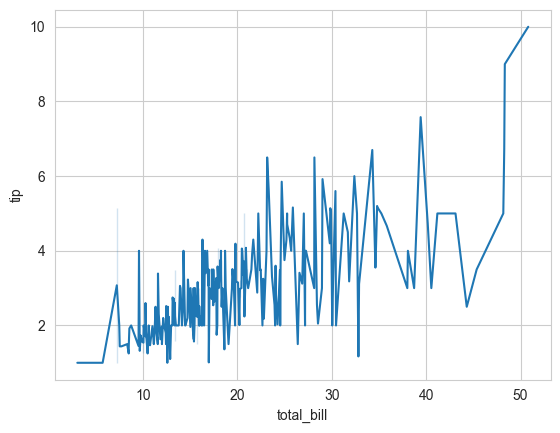

In [13]:
sns.lineplot(data=tips, # choose our dataset
x='total_bill', # define our x variable
y='tip') # define our y variable

In [39]:
sns.set_style('whitegrid')

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

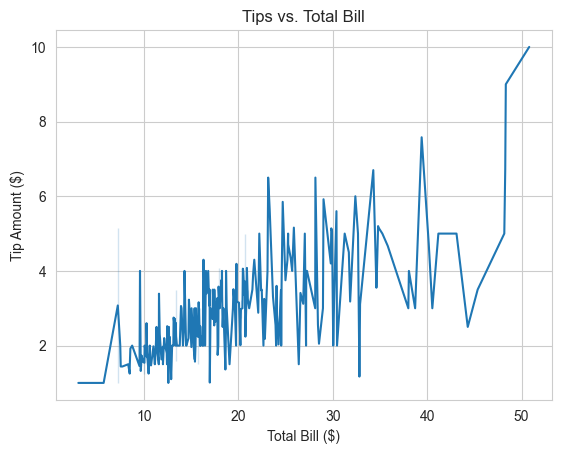

In [40]:
tipgraph = sns.lineplot(data=tips, x='total_bill', y='tip')

tipgraph.set(title='Tips vs. Total Bill', xlabel='Total Bill ($)', ylabel='Tip Amount ($)')

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

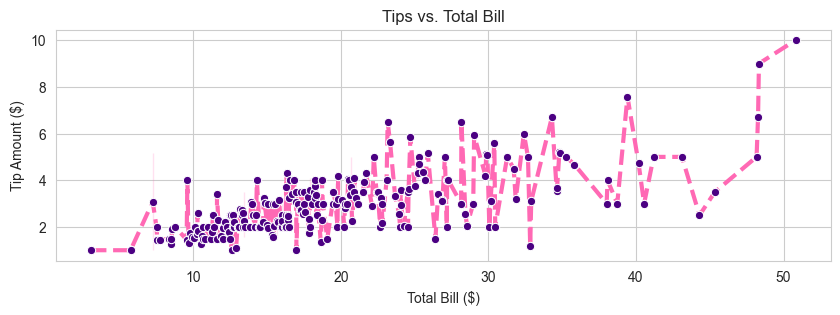

In [19]:
fig = plt.subplots(figsize=(10, 3))

tipgraph = sns.lineplot(data=tips,
x='total_bill',
y='tip',
color = 'hotpink',
linestyle = '--',
linewidth = 3,
marker = 'o',
markerfacecolor = 'indigo')

tipgraph.set(title='Tips vs. Total Bill',
xlabel='Total Bill ($)',
ylabel='Tip Amount ($)')

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

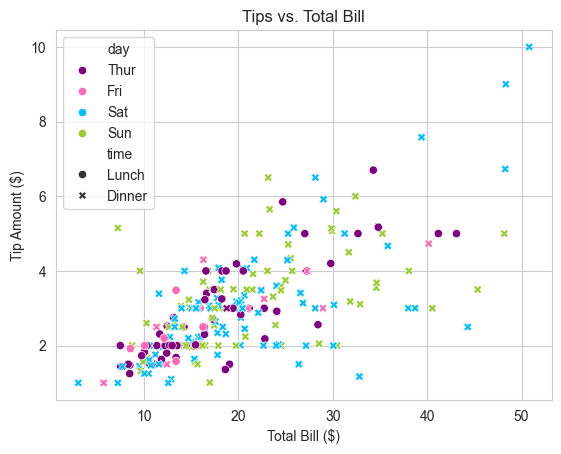

In [21]:
tipgraph = sns.scatterplot(data=tips, x='total_bill', y='tip', style = 'time', hue = 'day', palette = ['purple', 'hotpink', 'deepskyblue','yellowgreen'])
tipgraph.set(title='Tips vs. Total Bill',
xlabel='Total Bill ($)',
ylabel='Tip Amount ($)')

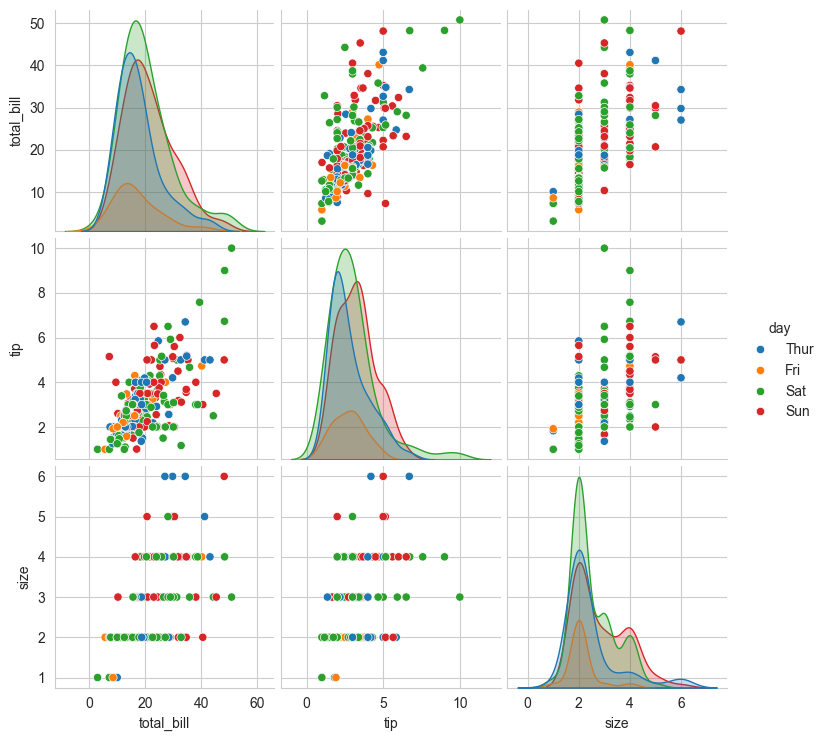

In [22]:
sns.pairplot(
data = tips,
hue = 'day')

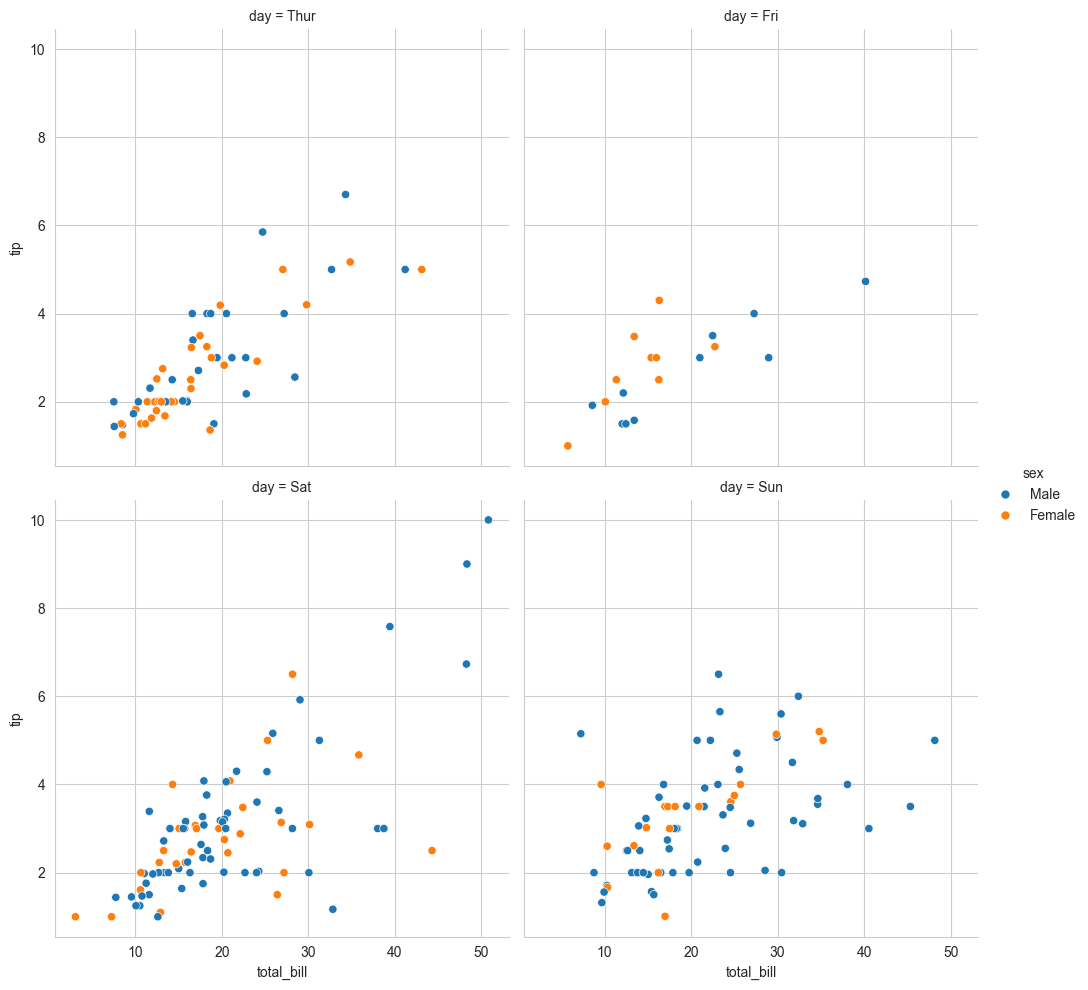

In [ ]:
# Create a Seaborn relational plot 
daysplot = sns.relplot(
    data=tips,          # DataFrame providing the data source
    x="total_bill",     # Column mapped to x-axis values
    y="tip",            # Column mapped to y-axis values
    hue="sex",          # Color-code points by the 'sex' category 
    col="day",          # Create separate subplot panels for each unique 'day' value
    kind="scatter",     # Use scatter plot instead of line plot 
    col_wrap=2          # Wrap subplot grid to 2 columns 
)

In [25]:
import plotly.graph_objects as go # 'go' is 'graph objects’
x1 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])

In [26]:
graph = go.Figure()

graph.add_trace(go.Bar(x=x1, y=y1))

graph.update_layout(
title="Pirate Scores",
xaxis_title="Pirates",
yaxis_title="Score")

graph.show()

In [27]:
graph = go.Figure()
graph.add_trace(go.Scatter(x=x1, y=y1, mode='markers', marker=dict(
size=15, # point size
color='hotpink', # point colour
opacity=1, # point transparency/alpha
line=dict(width=5, color='purple') # point outline
# we want points for a scatter plot
)))
graph.update_layout(
title='Interactive Pirate Plot',
xaxis_title='Pirates',
yaxis_title='Scores',
width=500, height=500)

In [28]:
from wordcloud import WordCloud
df = pd.read_csv("https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/movie_quotes.csv",
on_bad_lines='skip')
df

,quote,movie,type,year
0,"Do, or do not. There is no try.",Star Wars: Episode V - The Empire Strikes Back,movie,1890
1,Listen to them. Children of the night. What mu...,Dracula,movie,1931
2,It's alive! It's alive!,Frankenstein,movie,1931
3,"Oh, no, it wasn't the airplanes. It was Beauty...",King Kong,movie,1933
4,"Magic Mirror on the wall, who is the fairest o...",Snow White and the Seven Dwarves,movie,1937
...,...,...,...,...
727,I didn't know if you were lost. Stick with me....,Us,movie,2019
728,This guy's awesome! He's holding his own while...,Dragon Ball Super: Broly,movie,2019
729,"Murder is murder, it don’t matter who you are.",Black and Blue,movie,2019
730,You know what a lion is? A lion is a strong an...,Between Two Ferns: The Movie,movie,2019


(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

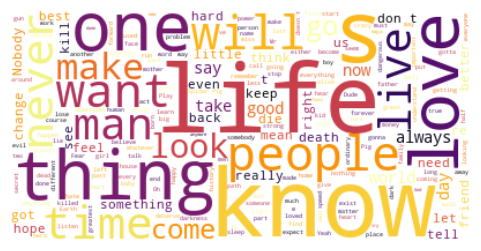

In [31]:
# join all our text from each row from our quote column into a string
text = " ".join(each for each in df.quote)
# generate our wordcloud image
wordcloud = WordCloud(background_color="white",
colormap = 'inferno').generate(text)
# use matplotlib syntax to put our image in a figure
fig, ax = plt.subplots(figsize=(7, 3))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis("off")

/Users/nyahbay/visualization-env/lib/python3.11/site-packages/matplotlib_venn/_util.py:32: UserWarning:

venn2_unweighted is deprecated. Use venn2 with the appropriate layout_algorithm instead.



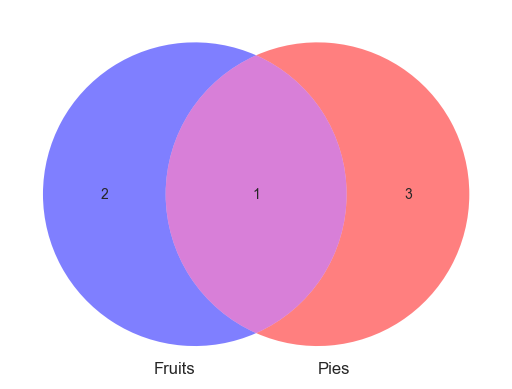

In [32]:
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted

A = set(["apple", "banana", "watermelon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])

diagram = venn2_unweighted([A, B],
set_labels = ('Fruits', 'Pies'),
set_colors=("blue", "red"),
alpha=0.5)
plt.show()

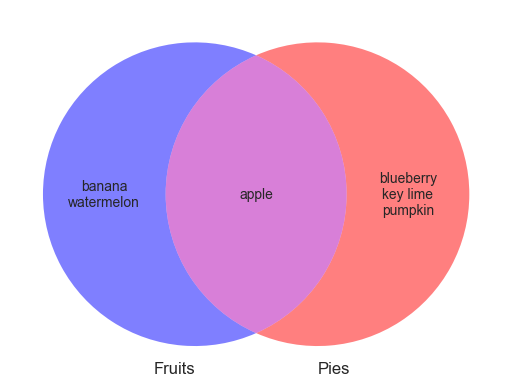

In [43]:
diagram = venn2_unweighted([A, B],
set_labels = ('Fruits', 'Pies'),
set_colors=("blue", "red"),
alpha=0.5)

diagram.get_label_by_id("10").set_text("\n".join(A - B))
diagram.get_label_by_id("11").set_text("\n".join(A & B))
diagram.get_label_by_id("01").set_text("\n".join(B - A))

plt.show()

# Activity

### How did this diagram of the Brooks use rational, moral, and emotional appeal to make a case to its audiences?

The Brookes diagram combines rational, moral, and emotional appeals to argue against the slave trade. It uses a technical, almost blueprint-style layout with measurements, deck plans, and exact counts of enslaved people to make the evidence look factual and objective, appealing to logic. At the same time, showing human bodies packed tightly together like cargo highlights the moral wrongness of treating people as property. Visually, the overcrowding and lack of space create a strong emotional reaction, making viewers feel the confinement and suffering. Together, the scientific presentation and shocking imagery make the cruelty seem both undeniable and deeply inhumane.

# Activity

### How are they different?

Left: static bar chart (mean ratings by instructor gender)
Right: interactive text/word-frequency dashboard

Bar chart: 
- Static summary plot
- Shows averages with error bars
- Compares four groups (actual/perceived, male/female)

Interactive language visualization:
- Interactive interface
- Shows word usage patterns from reviews
- Includes search/filtering

### What does each visualization ‘do’

Bar chart:
- Highlights differences in means
- Supports statistical interpretation (error bars, sample size)

Interactive language visualization:
- Enables exploration of language bias
- Allows users to query words
- Shows distribution and frequency

### What are the pros and cons of each?

Bar chart:

Pros
- Simple 
- Easy to compare groups
- Good for reporting results

Cons
- Limited to predefined categories
- Not interactive, less engaging

Interactive language visualization:

Pros
- Handles large text data well
- More engaging 

Cons
- Harder to summarize quickly
- Can overwhelm users
- Requires interaction to understand

# Activity

### What types of changes occur when we interact with this dynamic data visualization?

- Different words lead to different frequencies plotted
- all ratings/only positive/only negative

### Which spatial and retinal elements stay constant? Which change?

Spatial elements

Stay constant:
- X-axis 
- Y-axis 

Change:
- Point positions
- Category order

Retinal elements

Stay constant:
- Gender colours
- Symbol type 

Change:


### If you were redesigning this viz, would you choose to make different changes? Why or why not?

Recommended improvements: give recommended phrase inputs

Why? prevent confusion, also gives ideas to user. 